In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
AUS = pd.read_csv('Data/AustraliaGP.csv')
CHI = pd.read_csv('Data/ChinaGP.csv')
JAP = pd.read_csv('Data/JapanGP.csv')
MIA  = pd.read_csv('Data/MiamiGP.csv')

In [4]:
TRA = pd.concat([AUS,CHI,JAP,MIA],axis=0)

In [5]:
TRA

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_Laptime(s),Longest_Stint,Tyre_Compound,Qualifying_Time(s),Starting_Pos,Race_Result
0,ALB,83.130,81.847,81.664,36.650031,20.898312,42.942393,100.398929,11.0,HARD,80.941,15.0,12.0
1,ANT,81.376,79.943,80.324,36.042935,19.788161,41.798556,95.665077,15.0,HARD,78.811,2.0,2.0
2,BEA,82.682,81.326,80.778,39.039839,20.835774,41.873786,102.072750,15.0,HARD,80.311,12.0,7.0
3,BOR,81.696,81.668,80.459,39.209964,20.777286,46.708920,99.549182,9.0,MEDIUM,80.221,10.0,9.0
4,BOT,84.022,83.660,83.514,37.285821,20.556821,43.604600,101.500360,15.0,MEDIUM,83.244,19.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17,PIA,89.758,88.108,92.079,39.577889,40.305273,33.269778,111.682429,5.0,MEDIUM,88.500,7.0,3.0
18,RUS,90.100,88.493,92.387,39.324091,40.503000,34.202357,106.589556,3.0,MEDIUM,88.197,5.0,4.0
19,SAI,90.930,90.224,94.008,39.058700,41.538333,31.354167,111.177600,6.0,MEDIUM,89.568,13.0,9.0
20,STR,92.959,NaN,95.009,37.744000,39.904000,43.944667,125.395000,3.0,MEDIUM,91.164,18.0,17.0


In [6]:
TRA.isnull().sum()

Driver                0
FP1_BestTime(s)       0
FP2_BestTime(s)       5
FP3_BestTime(s)       4
Sector1Time(s)        3
Sector2Time(s)        2
Sector3Time(s)        2
Average_Laptime(s)    3
Longest_Stint         2
Tyre_Compound         2
Qualifying_Time(s)    3
Starting_Pos          3
Race_Result           1
dtype: int64

In [7]:
TRA.dropna(subset=['Qualifying_Time(s)','Race_Result'],inplace=True)

In [8]:
TRA.isnull().sum()

Driver                0
FP1_BestTime(s)       0
FP2_BestTime(s)       4
FP3_BestTime(s)       2
Sector1Time(s)        2
Sector2Time(s)        1
Sector3Time(s)        1
Average_Laptime(s)    2
Longest_Stint         1
Tyre_Compound         1
Qualifying_Time(s)    0
Starting_Pos          0
Race_Result           0
dtype: int64

In [11]:
TRA['FP2_BestTime(s)'].fillna(TRA['FP2_BestTime(s)'].median(),inplace=True)
TRA['FP3_BestTime(s)'].fillna(TRA['FP3_BestTime(s)'].median(),inplace=True)
TRA['Sector1Time(s)'].fillna(TRA['Sector1Time(s)'].median(),inplace=True)
TRA['Sector2Time(s)'].fillna(TRA['Sector2Time(s)'].median(),inplace=True)
TRA['Sector3Time(s)'].fillna(TRA['Sector3Time(s)'].median(),inplace=True)
TRA['Average_Laptime(s)'].fillna(TRA['Average_Laptime(s)'].mean(),inplace=True)
TRA['Longest_Stint'].fillna(TRA['Longest_Stint'].median(),inplace=True)
TRA['Tyre_Compound'].fillna(TRA['Tyre_Compound'].mode()[0],inplace=True)

/tmp/ipykernel_330580/2720948747.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  TRA['FP2_BestTime(s)'].fillna(TRA['FP2_BestTime(s)'].median(),inplace=True)
/tmp/ipykernel_330580/2720948747.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [12]:
TRA.isnull().sum()

Driver                0
FP1_BestTime(s)       0
FP2_BestTime(s)       0
FP3_BestTime(s)       0
Sector1Time(s)        0
Sector2Time(s)        0
Sector3Time(s)        0
Average_Laptime(s)    0
Longest_Stint         0
Tyre_Compound         0
Qualifying_Time(s)    0
Starting_Pos          0
Race_Result           0
dtype: int64

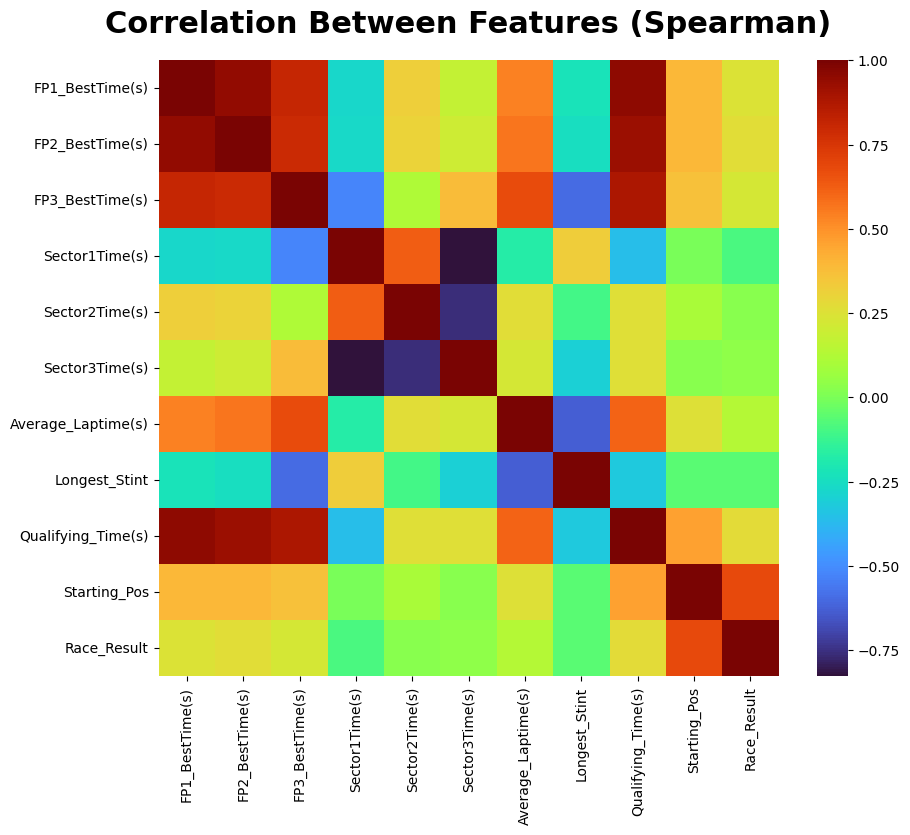

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(TRA.drop(['Tyre_Compound'], axis=1).iloc[:,1:].corr(method='spearman'), cmap='turbo')

plt.title('Correlation Between Features (Spearman)', fontsize=22, fontweight='bold',pad=20)
plt.savefig('Plots/Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


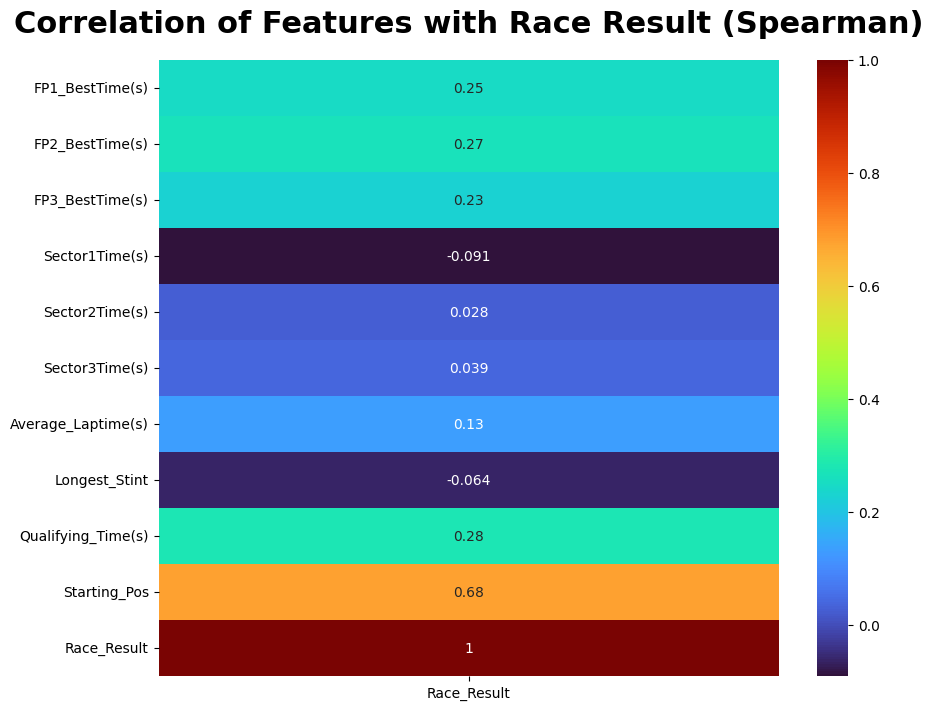

In [14]:
corr = TRA.drop(['Tyre_Compound'], axis=1).iloc[:,1:].corr(method='spearman')[['Race_Result']]
plt.figure(figsize=(10,8))
plt.title('Correlation of Features with Race Result (Spearman)', fontsize=22, fontweight='bold',pad=20)
sns.heatmap(corr, annot=True, cmap='turbo')
plt.savefig('Plots/Feature_RaceResult_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
TRA['Best_Time_for_Lap'] = TRA['Sector1Time(s)'] + TRA['Sector2Time(s)'] + TRA['Sector3Time(s)']

In [22]:
df = TRA.drop(['Tyre_Compound','Sector1Time(s)','Sector2Time(s)','Sector3Time(s)','Longest_Stint','Best_Time_for_Lap'], axis=1)

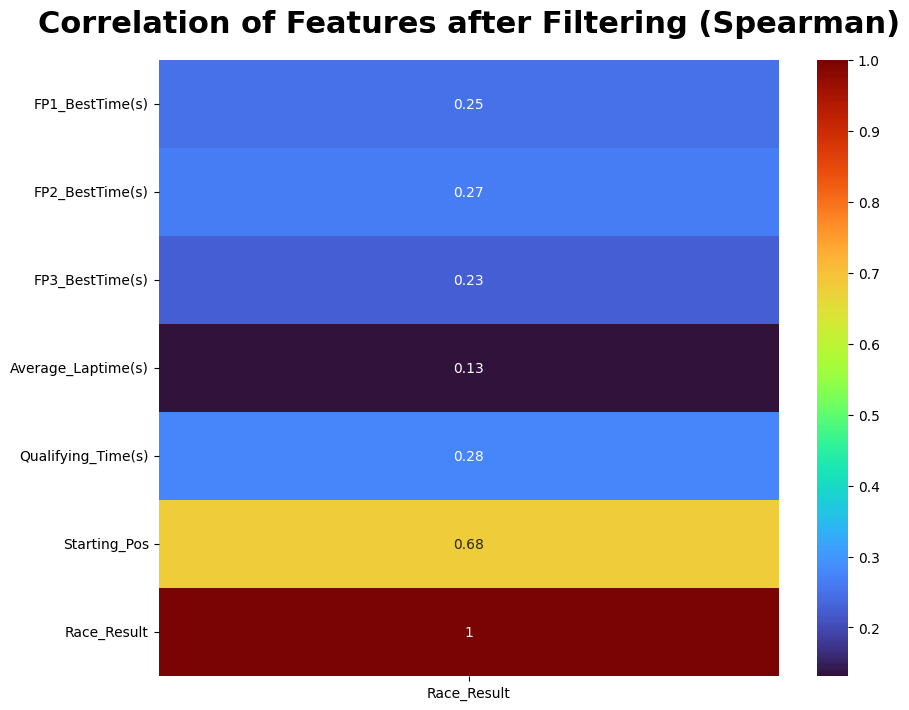

In [24]:
corr = df.iloc[:,1:].corr(method='spearman')[['Race_Result']]
plt.figure(figsize=(10,8))
plt.title('Correlation of Features after Filtering (Spearman)', fontsize=22, fontweight='bold',pad=20)
sns.heatmap(corr, annot=True, cmap='turbo')
plt.savefig('Plots/Feature_RaceResult_Correlation_after_Filter.png', dpi=300, bbox_inches='tight')
plt.show()